The attention mechanism was introduced to improve the performance of the encoder-decoder model for machine translation. The idea behind the attention mechanism was to permit the decoder to utilize the most relevant parts of the input sequence in a flexible manner, by a weighted combination of all the encoded input vectors, with the most relevant vectors being attributed the highest weights.

In this tutorial, you will discover the attention mechanism and its implementation.

## The Attention Mechanism

The attention mechanism was introduced by Bahdanau et al. (2014) to address the bottleneck problem that arises with the use of a fixed-length encoding vector, where the decoder would have limited access to the information provided by the input. This is thought to become especially problematic for long and/or complex sequences, where the dimensionality of their representation would be forced to be the same as for shorter or simpler sequences.

Note that Bahdanau et al.’s attention mechanism is divided into the step-by-step computations of the alignment scores, the weights, and the context vector:
* **Alignment scores**: The alignment model takes the encoded hidden states, $h_{i}$, and the previous decoder output $s_{t-1}$, to compute a score $e_{t,i}$, that indicates how well the elements of the input sequence align with the current output at the position $t$   
The alignment model is represented by a function, $a(.)$, which can be implemented by a feedforward neural network:  
$e_{t,i} = a(\mathbf{s}_{t-1}, \mathbf{h}_i)$  
* **Weights**: The weights, $\alpha_{t,i}$, are computed by applying a softmax operation to the previously computed alignment scores:  
$\alpha_{t,i} = \text{softmax}(e_{t,i})$
* **Context vector**: A unique context vector, $c_{t}$, is fed into the decoder at each time step. It is computed by a weighted sum of all, $T$, encoder hidden states:  
$\mathbf{c}_t = \sum_{i=1}^T \alpha_{t,i} \mathbf{h}_i$

## The General Attention Mechanism
The general attention mechanism makes use of three main components, namely the queries, Q
, the keys, K
, and the values, V
.

If you had to compare these three components to the attention mechanism as proposed by Bahdanau et al., then the query would be analogous to the previous decoder output,
, while the values would be analogous to the encoded inputs,
. In the Bahdanau attention mechanism, the keys and values are the same vector.

The general attention mechanism then performs the following computations:

1. Each query vector, $q=s_{t-1}$, is matched against a database of keys to  compute a score value. This matching operation is computed as the dot product of the specific query under consideration with each key vector, $k_{i}$:  
$e_{\mathbf{q},\mathbf{k}_i} = \mathbf{q} \cdot \mathbf{k}_i$  

2. The scores are passed through a softmax operation to generate the weights:
 $\alpha_{\mathbf{q},\mathbf{k}_i} = \text{softmax}(e_{\mathbf{q},\mathbf{k}_i}) $

3. The generalized attention is then computed by a weighted sum of the value vectors, $v_{k_i}$, where each value vector is paired with a corresponding key:  
$\text{attention}(\mathbf{q}, \mathbf{K}, \mathbf{V}) = \sum_i \alpha_{\mathbf{q},\mathbf{k}_i} \mathbf{v}_{\mathbf{k}_i}$


Within the context of machine translation, each word in an input sentence would be attributed its own query, key, and value vectors. These vectors are generated by multiplying the encoder’s representation of the specific word under consideration with three different weight matrices that would have been generated during training.

In essence, when the generalized attention mechanism is presented with a sequence of words, it takes the query vector attributed to some specific word in the sequence and scores it against each key in the database. In doing so, it captures how the word under consideration relates to the others in the sequence. Then it scales the values according to the attention weights (computed from the scores) to retain focus on those words relevant to the query. In doing so, it produces an attention output for the word under consideration.

Attention: How relevant is the query word to the given key word?

# The Transformer Architecture

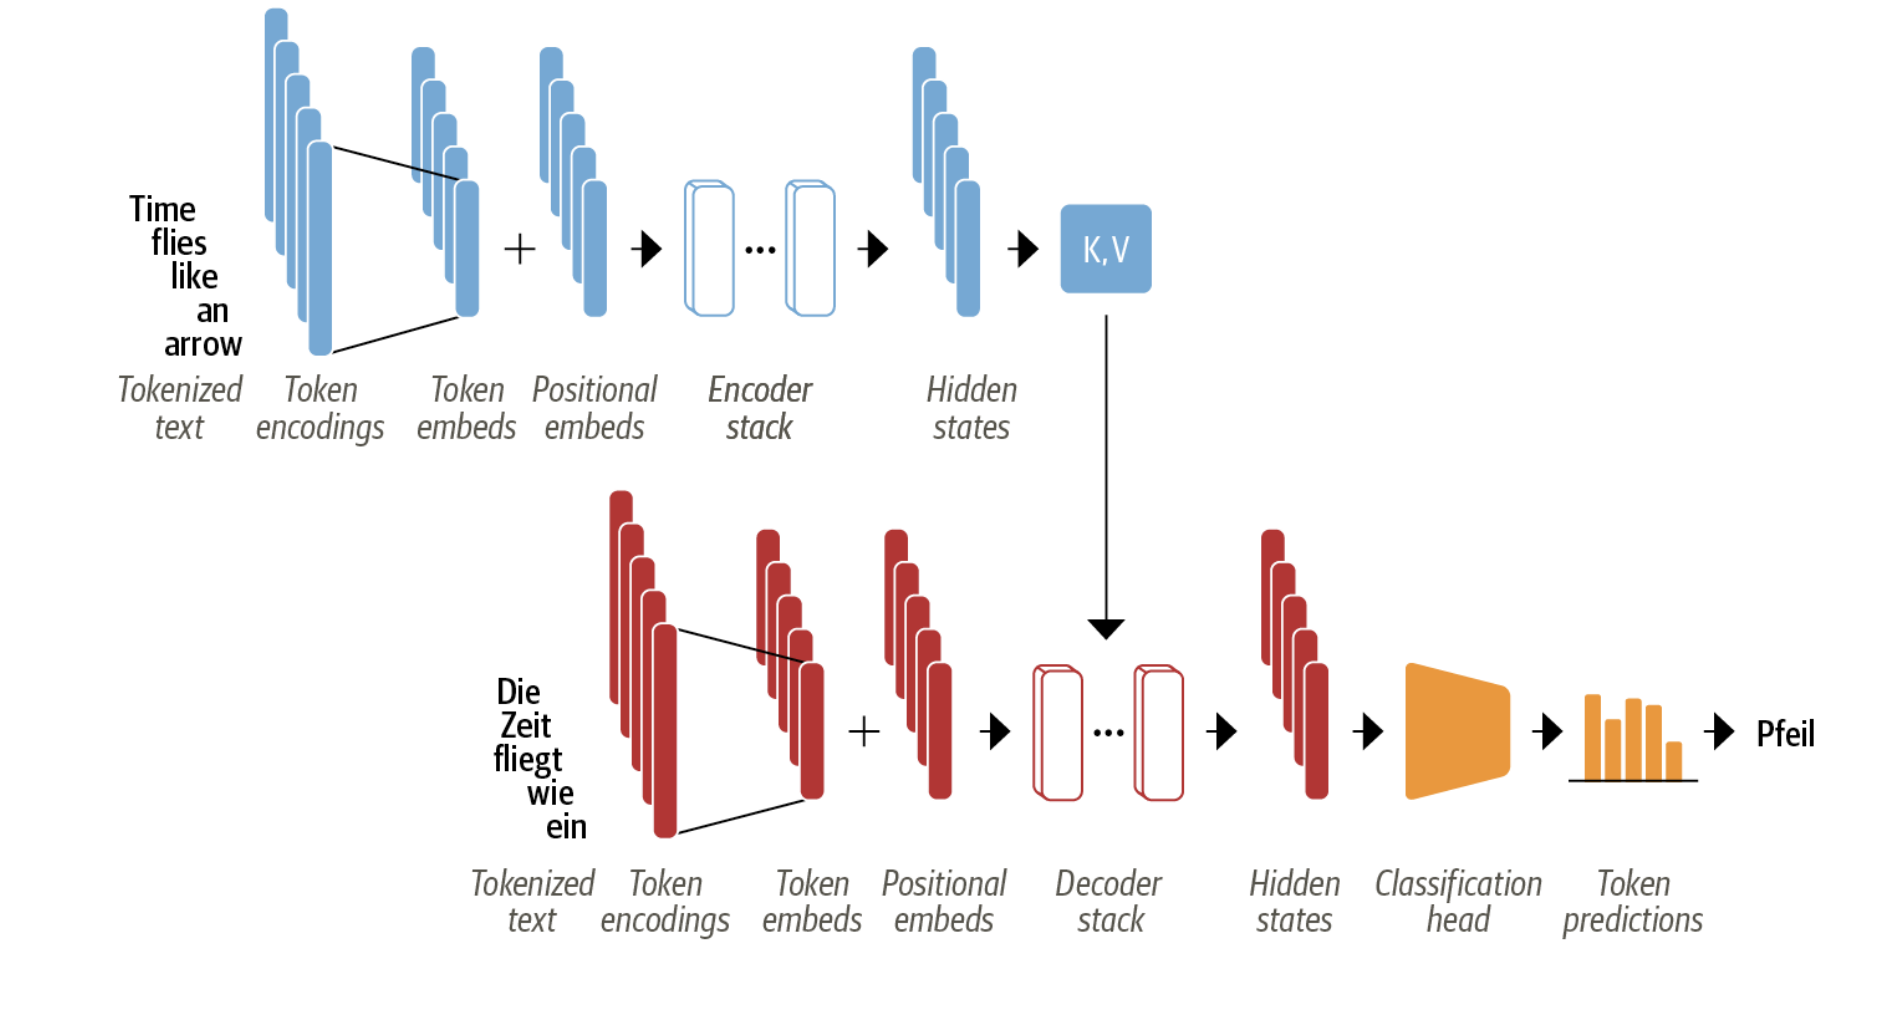

## The Encoder
In the following cells we are going to construct how to calculate attention in Pytorch as well as construct a general Encoder for the Transformer architecture.

#### Scaled dot-product attention

In [ ]:
# import torch
# x = torch.tensor([1, 2, 3, 4])
# print(x.size())
# print(torch.unsqueeze(x, 0).size())
# torch.unsqueeze(x, 1)

In [ ]:
# import torch
# x = torch.randn(2, 3)
# print(x.shape)
# x = torch.cat((x, x)) # same as torch.stack((x, x), dim=0)


# print(x.size())
# x
# # x = torch.stack((x, x), dim=1)

# # x = torch.stack((x, x), dim=2)

# # x = torch.stack((x, x), dim=-1)


In [ ]:
!pip install bertviz

In particular, we are going to see how to calculate Attention for a single sentence and compare it to what a trained Transformer model would interepret the sentence as.

`query`: A PyTorch tensor of shape (batch_size, sequence_length, query_dim). This tensor represents the query vectors for each token in the sequence.

`key`: A PyTorch tensor of shape (batch_size, sequence_length, key_dim). This tensor represents the key vectors for each token in the sequence.

`value`: A PyTorch tensor of shape (batch_size, sequence_length, value_dim). This tensor represents the value vectors for each token in the sequence.
Outputs:

`attended_values`: A PyTorch tensor of shape (batch_size, sequence_length, value_dim). This tensor represents the attended values obtained by combining the value vectors with the attention weights.
attention_weights: A PyTorch tensor of shape (batch_size, sequence_length, sequence_length). This tensor contains the attention weights indicating the importance of each token's value in producing the attended values.

$$
\text{Attention} = \text{softmax}\Big(\frac{QK^T}{\sqrt{d_k}}\Big)V
$$

In [ ]:
# let's use the Huggingface API to pull in
# a pretrained BERT model as well as the text
from transformers import AutoTokenizer
model_ckpt = "bert-base-uncased"
text = "time flies like an arrow"
# text = ["time flies like an arrow", 'how are you doing today?']
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True, padding=True)
inputs

In [ ]:
# see the beginning and end tokens
tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

In [ ]:
from torch import nn
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_ckpt)
token_emb = nn.Embedding(config.vocab_size, config.hidden_size)
token_emb

In [ ]:
inputs_embeds = token_emb(inputs.input_ids)
print(inputs_embeds.size())
print(inputs_embeds)

In [ ]:
# key.transpose(1,2).size()

In [ ]:
import torch
from math import sqrt

query = key = value = inputs_embeds
print('query/key/value size:',query.size())
print()

dim_k = key.size(-1)
print('dim_k :', dim_k)
print()

scores = torch.bmm(query, key.transpose(1,2)) / sqrt(dim_k)
print('scores size:',scores.size())
print()

# these are the raw scores
print('raw scores', scores)

In [ ]:
query.size()

key.size()
# key.transpose(1,2).size()

In [ ]:
import torch.nn.functional as F
# let's feed them through softmax
weights = F.softmax(scores, dim=-1)
weights.sum(dim=-1)
print(weights.size())
print(weights)

In [ ]:
# the new sentence representation
# combined with the attention weights
attn_outputs = torch.bmm(weights, value)
print(attn_outputs.shape)
print(attn_outputs)

In [ ]:
def scaled_dot_product_attention(query, key, value):
    dim_k = query.size(-1)
    scores = torch.bmm(query, key.transpose(1, 2)) / sqrt(dim_k)
    weights = F.softmax(scores, dim=-1)
    return torch.bmm(weights, value)

In [ ]:
weights[0].squeeze(0)

In [ ]:
# visualize one version of this
# this is before any training takes place
import seaborn as sns
x_axis_labels = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
y_axis_label = x_axis_labels
sns.heatmap(weights[0].squeeze(0).detach().numpy(),
            cmap="Blues",
            xticklabels=x_axis_labels,
            yticklabels=y_axis_label)

In [ ]:
import pandas as pd
pd.DataFrame(weights[0].squeeze(0).detach().numpy(),
             index=x_axis_labels,
             columns=y_axis_label)

In [ ]:
from transformers import AutoModel

model = AutoModel.from_pretrained(model_ckpt, output_attentions=True)
text = "time flies like an arrow"
inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True, padding=True)
with torch.no_grad():
  outputs = model(**inputs)
bert_embeddings = outputs.last_hidden_state

query = key = value = bert_embeddings
dim_k = key.size(-1)
scores = torch.bmm(query, key.transpose(1,2)) / sqrt(dim_k)
weights = F.softmax(scores, dim=-1)
# visualize one version of this
# this is before any training takes place
import seaborn as sns
x_axis_labels = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
y_axis_label = x_axis_labels
sns.heatmap(weights[0].squeeze(0).detach().numpy(),
            cmap="Blues",
            xticklabels=x_axis_labels,
            yticklabels=y_axis_label)



In [ ]:
import pandas as pd
pd.DataFrame(weights[0].squeeze(0).detach().numpy(),
             index=x_axis_labels,
             columns=y_axis_label)

In [ ]:
# after training the transformer
# you can begin seeing how these words relate to each other
from transformers import AutoTokenizer
from bertviz.transformers_neuron_view import BertModel
from bertviz.neuron_view import show

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = BertModel.from_pretrained(model_ckpt)
text = "The dog went to the park to play with its toy"
show(model, "bert", tokenizer, text, display_mode="light", layer=0, head=8)

#### Multi-headed attention
Let's code in Pytorch what multi headed attention would look like.

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, head_dim)
        self.k = nn.Linear(embed_dim, head_dim)
        self.v = nn.Linear(embed_dim, head_dim)

    def forward(self, hidden_state):
        attn_outputs = scaled_dot_product_attention(
            self.q(hidden_state), self.k(hidden_state), self.v(hidden_state))
        return attn_outputs

In [ ]:
config.num_attention_heads
768//12

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        embed_dim = config.hidden_size
        num_heads = config.num_attention_heads
        head_dim = embed_dim // num_heads
        self.heads = nn.ModuleList(
            [AttentionHead(embed_dim, head_dim) for _ in range(num_heads)]
        )
        self.output_linear = nn.Linear(embed_dim, embed_dim)

    def forward(self, hidden_state):
        x = torch.cat([h(hidden_state) for h in self.heads], dim=-1)
        x = self.output_linear(x)
        return x

In [ ]:
multihead_attn = MultiHeadAttention(config)
attn_output = multihead_attn(inputs_embeds)
attn_output.size()


In [ ]:
#hide_output
from bertviz import head_view
from transformers import AutoModel

model = AutoModel.from_pretrained(model_ckpt, output_attentions=True)

sentence_a = "time flies like an arrow"
sentence_b = "fruit flies like a banana"

viz_inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt')
attention = model(**viz_inputs).attentions
sentence_b_start = (viz_inputs.token_type_ids == 0).sum(dim=1)
tokens = tokenizer.convert_ids_to_tokens(viz_inputs.input_ids[0])

head_view(attention, tokens, sentence_b_start, heads=[8])

### The Feed-Forward Layer

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.linear_2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, x):
        x = self.linear_1(x)
        x = self.gelu(x)
        x = self.linear_2(x)
        x = self.dropout(x)
        return x

In [ ]:
feed_forward = FeedForward(config)
ff_outputs = feed_forward(attn_outputs)
ff_outputs.size()

In [ ]:
# output of the encoder block
print(ff_outputs)

### Adding Layer Normalization

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(config.hidden_size)
        self.layer_norm_2 = nn.LayerNorm(config.hidden_size)
        self.attention = MultiHeadAttention(config)
        self.feed_forward = FeedForward(config)

    def forward(self, x):
        # Apply layer normalization and then copy input into query, key, value
        hidden_state = self.layer_norm_1(x)
        # Apply attention with a skip connection
        x = x + self.attention(hidden_state)
        # Apply feed-forward layer with a skip connection
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [ ]:
encoder_layer = TransformerEncoderLayer(config)
inputs_embeds.shape, encoder_layer(inputs_embeds).size()

### Positional Embeddings

In [ ]:
# input_ids = inputs.input_ids
# input_ids.size(1)

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embeddings = nn.Embedding(config.vocab_size,
                                             config.hidden_size)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings,
                                                config.hidden_size)
        self.layer_norm = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout()

    def forward(self, input_ids):
        # Create position IDs for input sequence
        seq_length = input_ids.size(1)
        position_ids = torch.arange(seq_length, dtype=torch.long).unsqueeze(0)
        # Create token and position embeddings
        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        # Combine token and position embeddings
        embeddings = token_embeddings + position_embeddings
        embeddings = self.layer_norm(embeddings)#optional
        embeddings = self.dropout(embeddings)#optional
        return embeddings

In [ ]:
embedding_layer = Embeddings(config)
embedding_layer(inputs.input_ids).size()

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = Embeddings(config)
        self.layers = nn.ModuleList([TransformerEncoderLayer(config)
                                     for _ in range(config.num_hidden_layers)])

    def forward(self, x):
        x = self.embeddings(x)
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
# this is what gets fed into the decoder
encoder = TransformerEncoder(config)
print(encoder(inputs.input_ids).size())
print((encoder(inputs.input_ids)))

### Adding a Classification Head

In [ ]:
class TransformerForSequenceClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encoder = TransformerEncoder(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, x):
        x = self.encoder(x)[:, 0, :] # select hidden state of [CLS] token
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [ ]:
config.num_labels = 3
encoder_classifier = TransformerForSequenceClassification(config)
encoder_classifier(inputs.input_ids).size()

In [ ]:
encoder_classifier(inputs.input_ids)